 Gini impurity and entropy from scratch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gini(p):
    """p = array of class proportions in a node, e.g. [0.5, 0.5]"""
    p = np.array(p)
    return 1 - np.sum(p**2)

def entropy(p):
    """Shannon entropy in bits"""
    p = np.array(p)
    p = p[p > 0]  # avoid log(0)
    return -np.sum(p * np.log2(p))

# Compare impurity for different splits of a binary class node
splits = {
    "Pure node       [10, 0]":  [1.0, 0.0],
    "Slightly mixed  [9, 1]":   [0.9, 0.1],
    "Mixed           [7, 3]":   [0.7, 0.3],
    "Maximally mixed [5, 5]":   [0.5, 0.5],
}

print(f"{'Node':28s} {'Gini':>8s} {'Entropy':>8s}")
print("-" * 46)
for name, p in splits.items():
    print(f"{name:28s} {gini(p):8.4f} {entropy(p):8.4f}")

Node                             Gini  Entropy
----------------------------------------------
Pure node       [10, 0]        0.0000  -0.0000
Slightly mixed  [9, 1]         0.1800   0.4690
Mixed           [7, 3]         0.4200   0.8813
Maximally mixed [5, 5]         0.5000   1.0000


plot both curves across all possible proportions

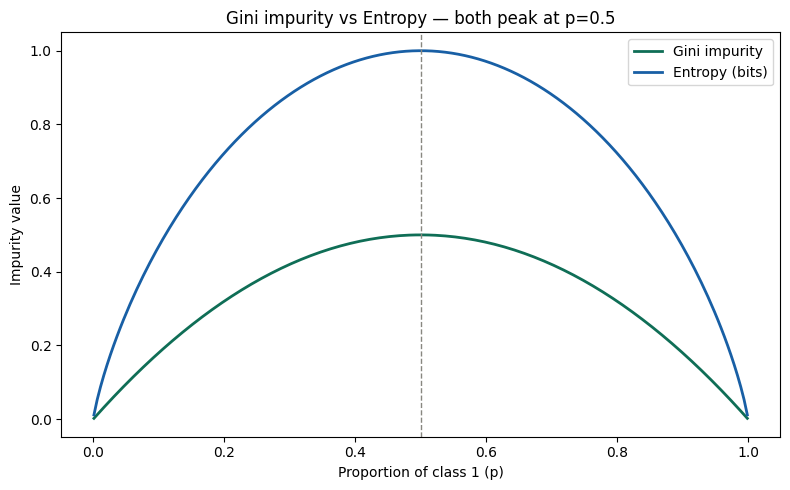

Max Gini (at p=0.5):    0.5000
Max Entropy (at p=0.5): 1.0000

Both metrics are 0 at p=0 or p=1 (pure node)
Both metrics peak at p=0.5 (maximally mixed node)
Entropy's curve is taller and uses log2 — slightly more computation


In [ ]:
p1 = np.linspace(0.001, 0.999, 200)
gini_vals    = [gini([p, 1-p]) for p in p1]
entropy_vals = [entropy([p, 1-p]) for p in p1]

plt.figure(figsize=(8, 5))
plt.plot(p1, gini_vals, color='#0F6E56', linewidth=2, label='Gini impurity')
plt.plot(p1, entropy_vals, color='#185FA5', linewidth=2, label='Entropy (bits)')
plt.axvline(0.5, color='#888780', linestyle='--', linewidth=1)
plt.xlabel('Proportion of class 1 (p)')
plt.ylabel('Impurity value')
plt.title('Gini impurity vs Entropy — both peak at p=0.5')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Max Gini (at p=0.5):    {gini([0.5,0.5]):.4f}")
print(f"Max Entropy (at p=0.5): {entropy([0.5,0.5]):.4f}")
print("\nBoth metrics are 0 at p=0 or p=1 (pure node)")
print("Both metrics peak at p=0.5 (maximally mixed node)")
print("Entropy's curve is taller and uses log2 — slightly more computation")

fit a decision tree on Iris and visualise it

Train accuracy: 1.0000
Test accuracy:  0.9333


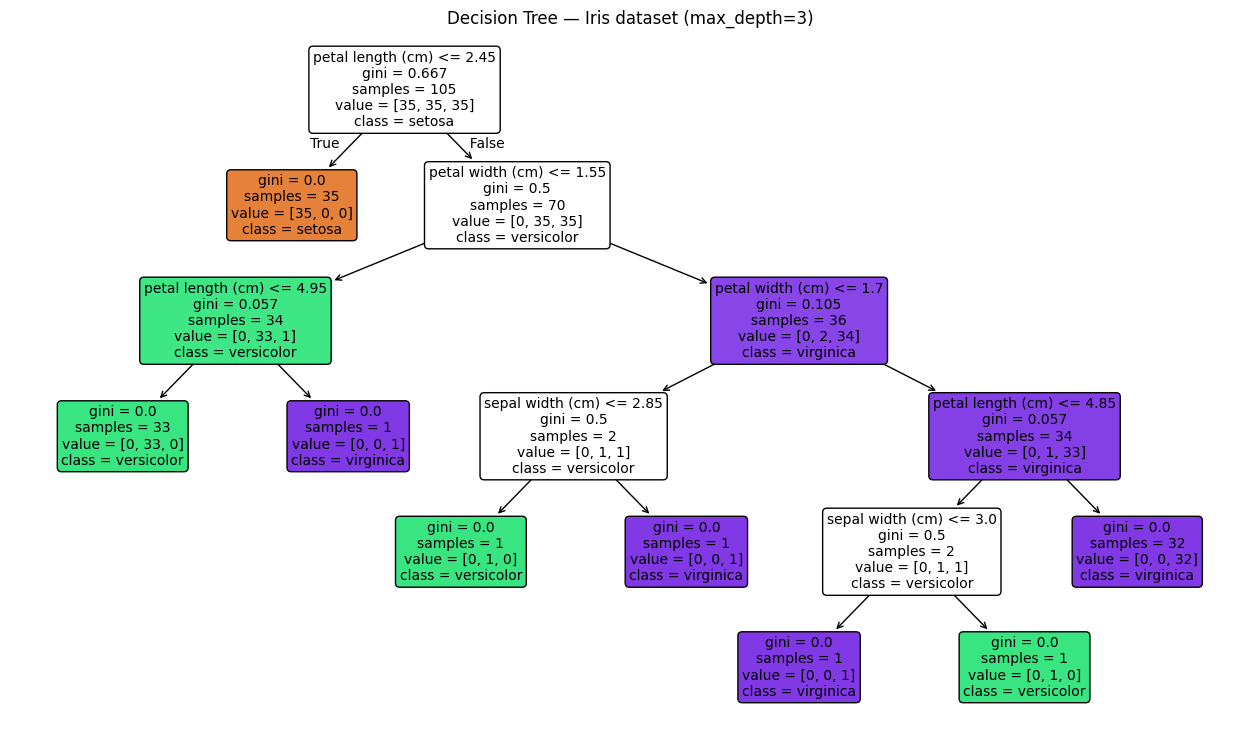

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Limit depth to 3 so the tree is readable
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)

print(f"Train accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {clf.score(X_test, y_test):.4f}")

plt.figure(figsize=(16, 9))
plot_tree(clf, feature_names=feature_names, class_names=class_names,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree — Iris dataset (max_depth=3)")
plt.show()